In [1]:
from IPython.core.debugger import prompt
from langgraph.graph import StateGraph , START,END
from typing import TypedDict , Literal
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from pydantic import BaseModel,Field
load_dotenv()

C:\Users\Archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
import os
model = ChatGroq(api_key=os.getenv("API_KEY")
                 ,temperature=0.0,
                 model = "llama-3.3-70b-versatile")




In [3]:
class sentiment(BaseModel):
    sentiment: Literal["negative","positive"]


In [4]:
structured_model= model.with_structured_output(sentiment)

In [5]:
promt= "tell the sentiment in this custumer -this is a good product"
ans = structured_model.invoke(promt)
print(ans)


sentiment='positive'


In [6]:
class review_state(TypedDict):
     review : str
     sentiment : Literal["negative","positive"]
     diagnosis : dict
     response : str

In [7]:
def check_sentiment(state:review_state )->Literal["negative_diagnosis","positive_response"]:
     if state['sentiment'] == "negative":
         return "negative_diagnosis"
     else:
         return "positive_response"
def positive_response(state:review_state ):
     promt = "thank the customer for the positive review"
     response = model.invoke(promt)
     return {'response':response.content}
def negative_diagnosis(state: review_state):
    prompt = f"This is a negative review from a customer: \"{state['review']}\"\nReturn the tone, urgency, and issue type."
    response = structured_model2.invoke(prompt)
    return {'diagnosis': response.model_dump()}
def negative_response(state:review_state ):
    diagnosis = state['diagnosis']
    prompt = f"""you are a support model you need to give resolution /n/n on from these tone  {diagnosis['tone']} issue type {diagnosis['issue_type']}, and urgency{diagnosis['urgency']}"""
    response = model.invoke(prompt)
    return {'response':response.content}


In [8]:
def sentiment_guess(state:review_state )->Literal["negative","positive"]:

    prompt=f"this is the review form the customer {state['review']} tell if its negative or positive"
    sentiment = structured_model.invoke(prompt)
    return {"sentiment":sentiment.sentiment}

In [9]:
class diagnosis(BaseModel):
    tone : Literal['angry','frustrated','disappointed','calm'] = Field(description="Tone of the diagnosis")
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')

In [10]:
structured_model2 = model.with_structured_output(diagnosis)


In [11]:
graph = StateGraph(review_state)

In [12]:
graph.add_node("sentiment guess",sentiment_guess)
graph.add_node("run diagnosis",negative_diagnosis)
graph.add_node("positive_response",positive_response)
graph.add_node("negative_response",negative_response)
graph.add_edge(START,"sentiment guess")

graph.add_edge("run diagnosis","negative_response")

graph.add_edge("negative_response",END)
graph.add_edge("positive_response",END)

In [13]:
graph.add_conditional_edges(
    "sentiment guess",       # source no
    check_sentiment,# ,   # function that decides where to go
    {
        "negative_diagnosis":"run diagnosis",
        "positive_response":"positive_response",
    }
)

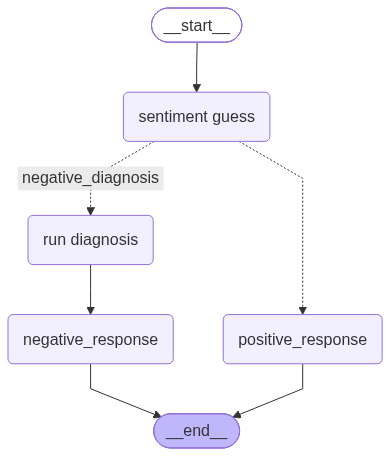

In [14]:
graph.compile()

In [15]:
review="i did not liked the product"

In [16]:
initial_state = {
      "review":review
}

In [17]:
workflow= graph.compile()

In [24]:
response = workflow.invoke(initial_state)
print(response)


{'review': 'i did not liked the product', 'sentiment': 'negative', 'diagnosis': {'tone': 'disappointed', 'urgency': 'low', 'issue_type': 'Other'}, 'response': "I apologize for the inconvenience you're experiencing. I'm here to help you with your issue, which seems to be of a different nature than what we typically encounter. \n\nTo better understand and address your concern, could you please provide more details about the issue you're facing? This will enable me to offer a more accurate and helpful resolution.\n\nIn the meantime, I want to assure you that I'm committed to finding a solution for you, even if it takes a bit more time and effort. Your satisfaction is important to me, and I appreciate your patience and cooperation in this matter.\n\nLet's work together to resolve this issue. Please feel free to share any additional information or context that might be relevant, and I'll do my best to provide a suitable resolution."}
